In [ ]:
from model_builder import ModelBuilder
from model_builder_keras import KerasModelBuilder
from preprocessing import Preprocessor
from plotting_other import Plotter
from plotting import plot_dataset
#from shapley import ProcessAttributor
from shapley_improved import ProcessAttributorSHAP
from shapley_improved_other import ProcessAttributorSHAPMLP

from universal_filtering import CustomSpearmanFilter
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
#from sklearn.linear_model import Ridge
#from sklearn.linear_model import Lasso
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

# Basic Deep Learning with Sklearn MLP
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

# Deep Learning with Keras Tensorflow
#import keras
from keras import layers, optimizers, callbacks, Sequential
#https://ipython.org/ipython-doc/3/config/extensions/autoreload.html
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
train_ampliseq = [
        pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260703T215123Z/datasets/ampliseq_1_0607.parquet"),
        pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260704T093159Z/datasets/ampliseq_2_0607.parquet"),
        pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260708T125031Z/datasets/ampliseq_triple_run.parquet")

]

test_ampliseq = pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260706T112716Z/datasets/ampliseq_3_0707.parquet")



In [32]:
training_data = pd.concat(train_ampliseq, ignore_index=True)
training_data = training_data
test_data = test_ampliseq
PNG_NAME = "mlp_pred_ampl"

features = [
    "delta_cpu_ns",
    "delta_io_bytes",
    "delta_net_send_bytes",
    "context_switches",
    "syscall_count",
    "delta_rss_memory",
    "delta_cpu_time_psutil",
    "delta_cpu_time_proc",
    "syscall_class_file",
    "syscall_class_network",
    "syscall_class_memory",
    "syscall_class_process",
    "syscall_class_other",
    "syscall_class_sched",
    "syscall_class_signal",
    "syscall_class_time",
    "delta_cycles",
    "delta_cache_misses",
    "delta_instructions",
    "delta_branch_instructions",
]


In [33]:
preprocessor_train = Preprocessor(training_data, features)
X_train_FULL, y_train, t_train, _ = preprocessor_train.preprocess_no_split()

Dropped 1 timestamps.


In [34]:
#plot_dataset(t_train, y_train, "multi_training")


In [35]:
#build_model = ExplainableBoostingRegressor( interactions=2, max_rounds=2000, n_jobs=-1, random_state=42)
model = RandomForestRegressor(n_estimators=100,  n_jobs=-1, random_state=42)
#build_model = MLPRegressor(activation="relu", solver="adam", random_state=42)



In [36]:
#These thresholds could be fine tuned
automatic_feature_selection = Pipeline(steps=[
    ('variance', VarianceThreshold(threshold=0.01)), #explain this

    ('decorrelate', CustomSpearmanFilter(threshold=0.80)),
    ('scaler', StandardScaler()),
    ('select_features', SelectFromModel(model, threshold='0.5*median'))
])

automatic_feature_selection.set_output(transform="pandas")
automatic_feature_selection.fit_transform(X_train_FULL, y_train)
good_features = automatic_feature_selection.get_feature_names_out().tolist()
X_train = X_train_FULL[good_features]
print("Selected columns:")
print(good_features)


#plot_dataset(t_train, y_train, "multi_training")

Selected columns:
['delta_cpu_ns', 'delta_io_bytes', 'delta_net_send_bytes', 'context_switches', 'syscall_count', 'syscall_class_network', 'syscall_class_memory', 'syscall_class_sched']


In [37]:
preprocessor_test = Preprocessor(test_data, good_features)
X_test, y_test, t_test , X_test_unaggregated = preprocessor_test.preprocess_no_split()

#plot_dataset(t_test, y_test, "multi_testing")

Dropped 1 timestamps.


In [38]:
X_train

,delta_cpu_ns,delta_io_bytes,delta_net_send_bytes,context_switches,syscall_count,syscall_class_network,syscall_class_memory,syscall_class_sched
_time,,,,,,,,
2026-07-03 21:51:24+00:00,221071144.0,159744.0,548428.0,1452.0,32087.0,186.0,0.0,0.0
2026-07-03 21:51:26+00:00,210475388.0,208896.0,546325.0,1320.0,32633.0,184.0,0.0,2.0
2026-07-03 21:51:28+00:00,212553738.0,237568.0,546104.0,1136.0,31570.0,185.0,0.0,0.0
2026-07-03 21:51:30+00:00,220385050.0,233472.0,549916.0,1344.0,31940.0,216.0,0.0,0.0
2026-07-03 21:51:33+00:00,215414332.0,159744.0,548197.0,1164.0,32226.0,196.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2026-07-08 16:31:50+00:00,258755453.0,237568.0,851626.0,1088.0,41706.0,192.0,0.0,0.0
2026-07-08 16:31:52+00:00,267027768.0,253952.0,856654.0,1038.0,41983.0,196.0,0.0,0.0
2026-07-08 16:31:55+00:00,261296703.0,274432.0,856231.0,1134.0,41773.0,193.0,0.0,1.0


In [39]:
plot_dataset(t_test, y_test, "multi_testing")

### Sklearn MLP

In [40]:
build_model_mlp = MLPRegressor(hidden_layer_sizes=(128,32,16),
                    activation='relu',
                    solver='adam',
                    learning_rate_init=0.0001,
                    max_iter=500,
                    #alpha = 0.0000675,
                    batch_size=64,
                    early_stopping=True,    # Crucial for time-series stability
                    #validation_fraction=0.1,
                    random_state=42)

In [41]:
builder = ModelBuilder(X_train, X_test, y_train, y_test, build_model_mlp, StandardScaler())
y_pred, learned_idle_power = builder.run_and_save_model()


  R² Score:  0.8975
  MAE:       4.49 Ws (2.36% of mean)
----------------------------------
The model's learned baseline idle interval energy is: 140.80 Ws
----------------------------------
/n


In [42]:
plotter = Plotter(y_pred,y_test, t_test,"mlp")#, window_start =50, window_end=200)
plotter.plot_and_save("", PNG_NAME)

In [43]:
#check if we ann pass this differently
#attributor = ProcessAttributorSHAPMLP( builder.X_test_scaled, builder.model, builder.scaler)
#attributor.attribute(X_test_unaggregated,good_features,t_test.values, "mlp_graphs_")

### Deep Learning with Keras

Build the 1D-CNN in Keras (Tutorials)

- https://keras.io/guides/sequential_model/
- https://keras.io/examples/timeseries/timeseries_classification_from_scratch/
- https://www.tensorflow.org/tutorials/structured_data/time_series#recurrent_neural_network
- https://keras.io/examples/timeseries/timeseries_classification_from_scratch/



In [44]:
num_features = len(good_features)

In [45]:
# Models used
# Convolutional Neural Network (1D)
cnn_model = Sequential([

    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    layers.BatchNormalization(),

    layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    layers.BatchNormalization(),

    #layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    #layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
    
])

# Feed Forward Neural Network
ffnn_model = Sequential([
    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.Flatten(),
    #layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    #layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
    
])

# LSTM Model
lstm_model = Sequential([
    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.BatchNormalization(),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(64, return_sequences=True),
    layers.Flatten(),
    #layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.2),
    #layers.Dense(32, activation='relu'),
    layers.Dense(1)
    
])

In [46]:
builder_lstm = KerasModelBuilder(X_train, X_test, y_train, y_test, lstm_model, StandardScaler())
y_pred_lstm, learned_idle_power = builder_lstm.run_and_save_model()

Epoch 1/30


112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 27130.3887 - mae: 161.7995 - val_loss: 15829.2061 - val_mae: 123.9419
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9258.7783 - mae: 92.6376 - val_loss: 5084.6782 - val_mae: 68.0466
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2696.9980 - mae: 46.8786 - val_loss: 1455.4474 - val_mae: 32.6739
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 815.4479 - mae: 21.1041 - val_loss: 612.2929 - val_mae: 15.4033
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 449.8532 - mae: 11.7289 - val_loss: 446.6926 - val_mae: 11.1919
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 371.8731 - mae: 10.6478 - val_loss: 383.0626 - val_mae: 10.4862
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 326.2665 - mae: 10.0657 - val_loss: 337.2006 - val_mae: 9.9166
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 290.5654 - mae: 9.6021 - val_loss: 300.6789 - val_mae: 9.5551
Epoc

In [47]:
#plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test, t_test= t_test,alg_name="lstm",window_start=150, window_end=200)
plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test, t_test= t_test,alg_name="lstm")
#plotter.plot_only("lstm_")
plotter.plot_and_save("ltsm_")

In [50]:
builder_cnn = KerasModelBuilder(X_train, X_test, y_train, y_test, cnn_model, StandardScaler())
y_pred_cnn, learned_idle_power = builder_cnn.run_and_save_model()

Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 19967.8965 - mae: 129.1136 - val_loss: 22614.8105 - val_mae: 148.8787
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 413.9790 - mae: 12.1991 - val_loss: 11352.1250 - val_mae: 104.8267
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 183.9335 - mae: 8.4282 - val_loss: 5639.4990 - val_mae: 73.5865
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 131.9564 - mae: 7.5218 - val_loss: 2129.1611 - val_mae: 44.5130
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 111.0476 - mae: 6.9883 - val_loss: 628.7755 - val_mae: 22.7690
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 99.2232 - mae: 6.9354 - val_loss: 134.5769 - val_mae: 7.7443
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 92.5751 - mae: 6.6552 - val_loss: 98.9978 - val_mae: 7.4265
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 83.2172 - mae: 6.3207 - val_loss: 75.2121 - val_mae: 5.8646
Epoch 9/30


In [51]:
plotter = Plotter(y_pred=y_pred_cnn,y_test=y_test, t_test= t_test,alg_name="cnn_1d")
#plotter.plot_only("cnn_1d")
plotter.plot_and_save("cnn_1d_")

In [52]:
#64-16 # Faster other models
#  R² Score:  0.9224
#  MAE:       5.53 Ws (2.75% of mean)
builder_ffnn = KerasModelBuilder(X_train, X_test, y_train, y_test, ffnn_model, StandardScaler())
y_pred_ffnn, learned_idle_power = builder_cnn.run_and_save_model()

Epoch 1/30


112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 51.2394 - mae: 4.9542 - val_loss: 69.2179 - val_mae: 5.6190
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 47.6749 - mae: 4.7105 - val_loss: 62.3438 - val_mae: 5.2839
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 50.9245 - mae: 4.9809 - val_loss: 73.5081 - val_mae: 5.5177
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 47.4042 - mae: 4.7646 - val_loss: 67.3515 - val_mae: 5.2364
Epoch 5/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 49.4811 - mae: 4.8323 - val_loss: 71.4797 - val_mae: 5.4474
Epoch 6/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 49.3758 - mae: 4.8773 - val_loss: 65.1162 - val_mae: 5.6211
Epoch 7/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 49.7457 - mae: 4.8988 - val_loss: 78.1617 - val_mae: 6.3185
Epoch 8/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 48.3307 - mae: 4.7724 - val_loss: 65.1429 - val_mae: 6.0481
Epoch 9/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

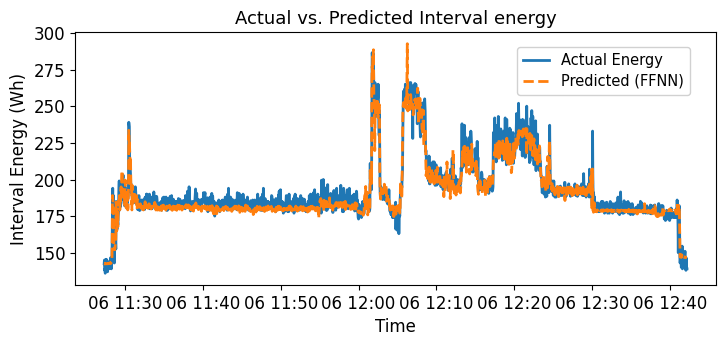

In [54]:
plotter = Plotter(y_pred=y_pred_ffnn,y_test=y_test, t_test= t_test,alg_name="ffnn")
plotter.plot_only("ffnn_")
plotter.plot_and_save("ffnn_")